In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def display(img, cmap = None):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap = cmap)

## Blurring

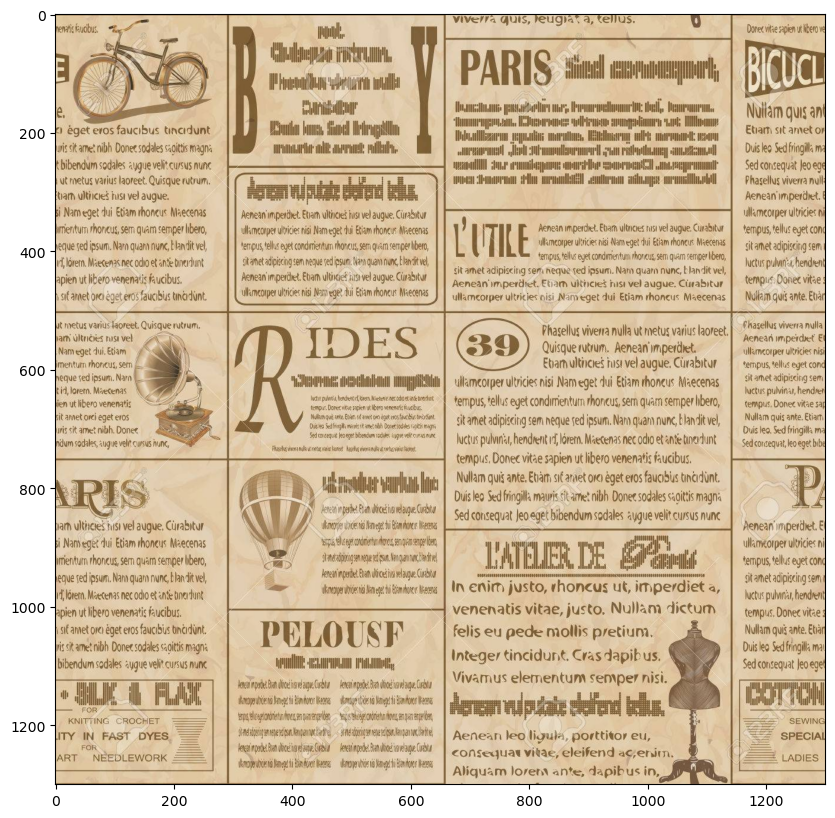

In [3]:
img_text= cv2.imread('image/text.jpg')
img_text  = cv2.cvtColor(img_text, cv2.COLOR_BGR2RGB)
display(img_text)

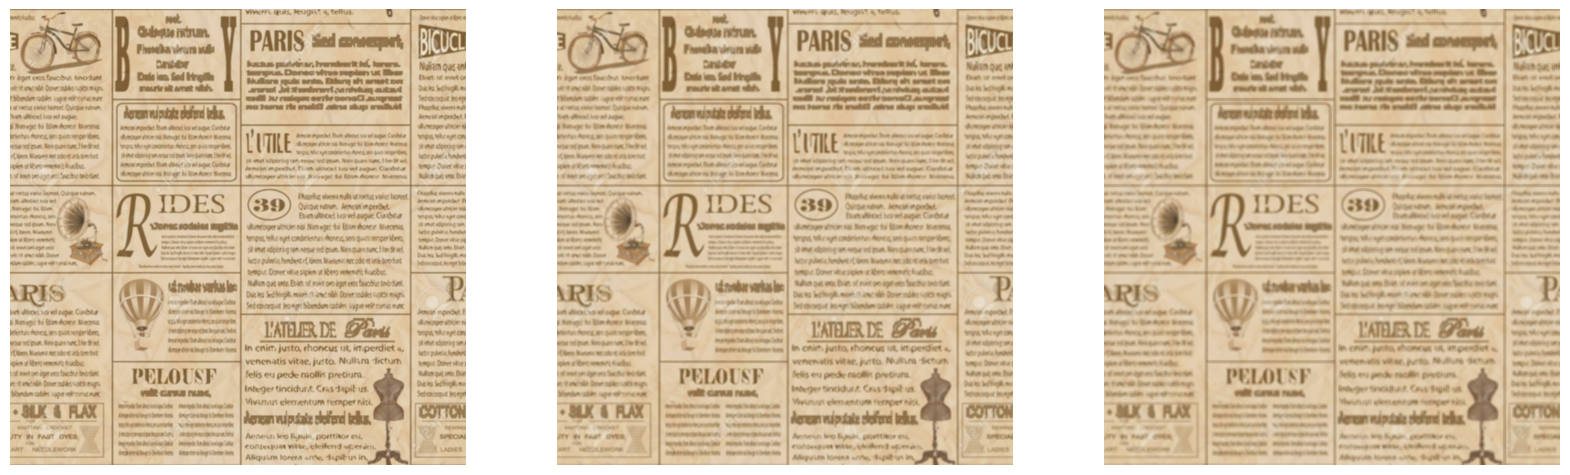

In [4]:
img = img_text.copy()
kernels = [5,7,9]
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (20,20))
for ind, s in enumerate(kernels):
    img_blurred = cv2.blur(img, ksize = (s,s))
    ax = axs[ind]
    ax.imshow(img_blurred)
    ax.axis('off')
plt.show()

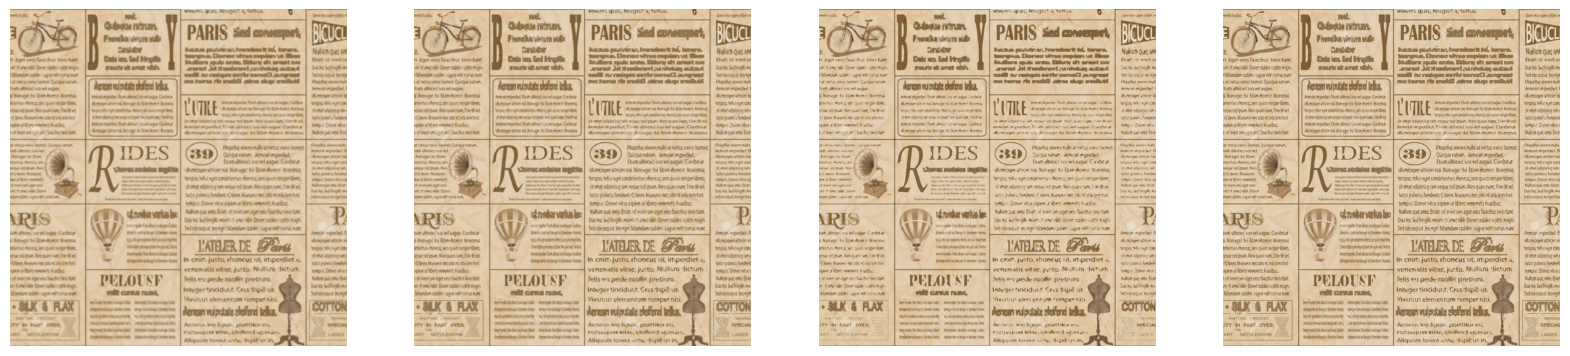

In [5]:
# blur the image

img_0 = cv2.blur(img, ksize = (5,5))
img_1 = cv2.GaussianBlur(img, ksize = (5,5), sigmaX = 0) # sigmax increases blu be strong
img_2 = cv2.medianBlur(img, 5)
img_3 = cv2.bilateralFilter(img, 5, sigmaSpace = 75, sigmaColor = 75) # color and intensity similarity

images = [img_0, img_1, img_2, img_3]
fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (20,20))
for ind, p in enumerate(images):
    ax = axs[ind]
    ax.imshow(p)
    ax.axis('off')
plt.show()

## Threshold

In [6]:
img = cv2.imread('image/gradation.png')

In [7]:
# thresholding variations

_, thresh_0 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, thresh_1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
_, thresh_2 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
_, thresh_3 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)
_, thresh_4 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)

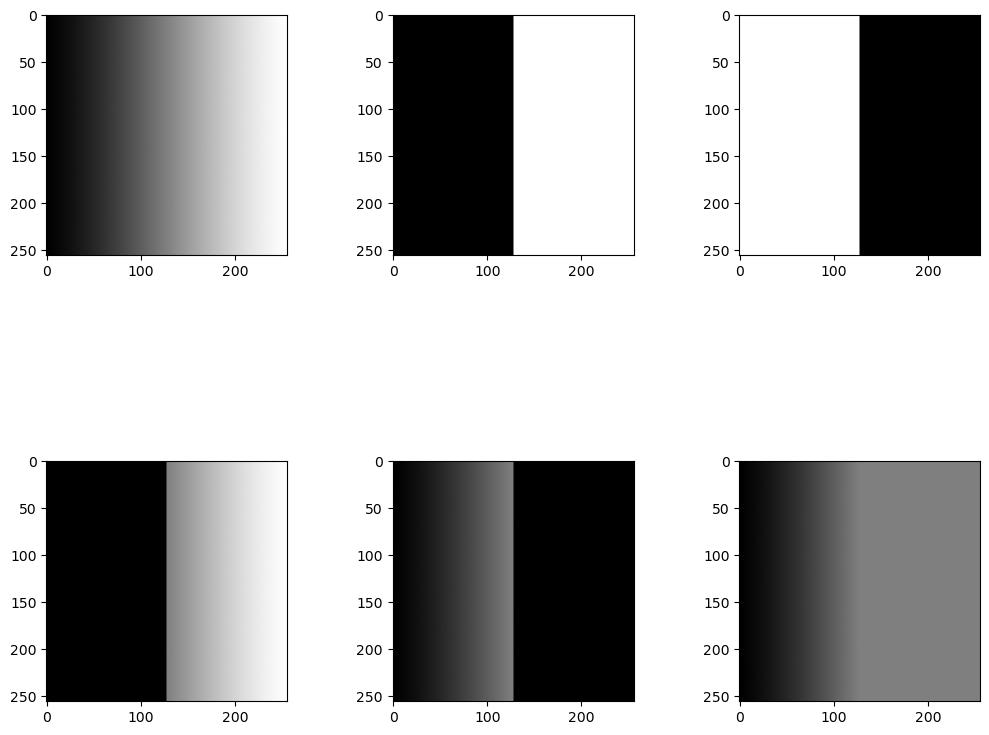

In [8]:
images = [img, thresh_0,thresh_1, thresh_2, thresh_3,thresh_4]
fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize = (10,10))
for ind, p in enumerate(images):
    ax = axs[ind//3, ind%3]
    ax.imshow(p)
plt.tight_layout(w_pad = 5)
plt.show()

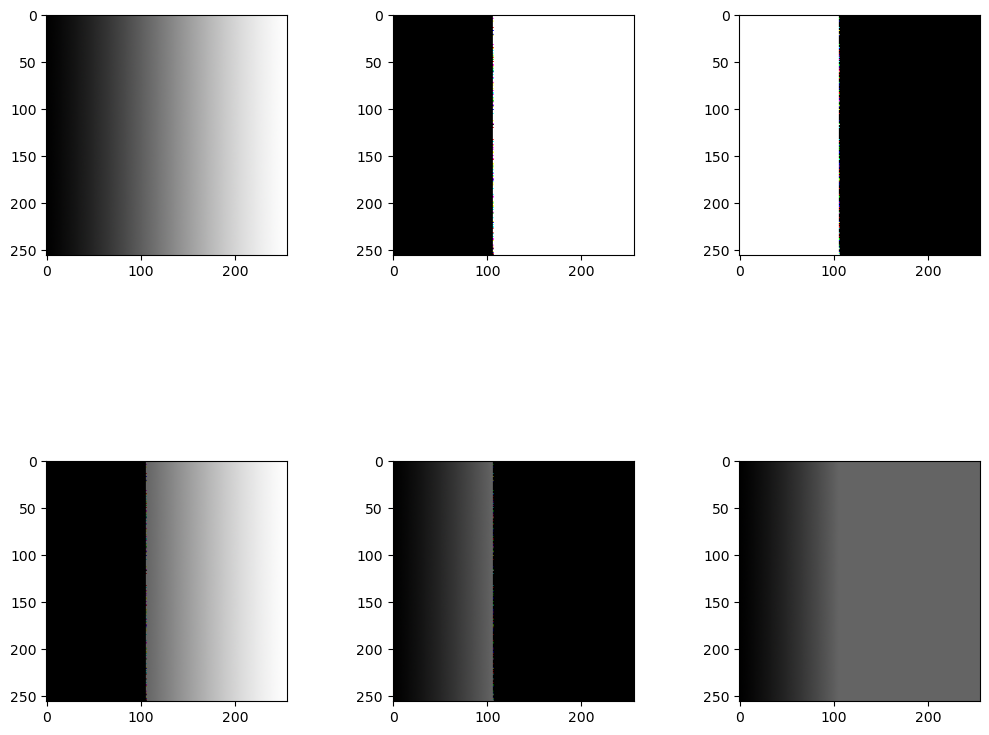

In [9]:
# thresholding variations  -2 change

_, thresh_0 = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)
_, thresh_1 = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY_INV)
_, thresh_2 = cv2.threshold(img, 100, 255, cv2.THRESH_TOZERO)
_, thresh_3 = cv2.threshold(img, 100, 255, cv2.THRESH_TOZERO_INV)
_, thresh_4 = cv2.threshold(img, 100, 255, cv2.THRESH_TRUNC)
images = [img, thresh_0,thresh_1, thresh_2, thresh_3,thresh_4]
fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize = (10,10))
for ind, p in enumerate(images):
    ax = axs[ind//3, ind%3]
    ax.imshow(p)
plt.tight_layout(w_pad = 5)
plt.show()

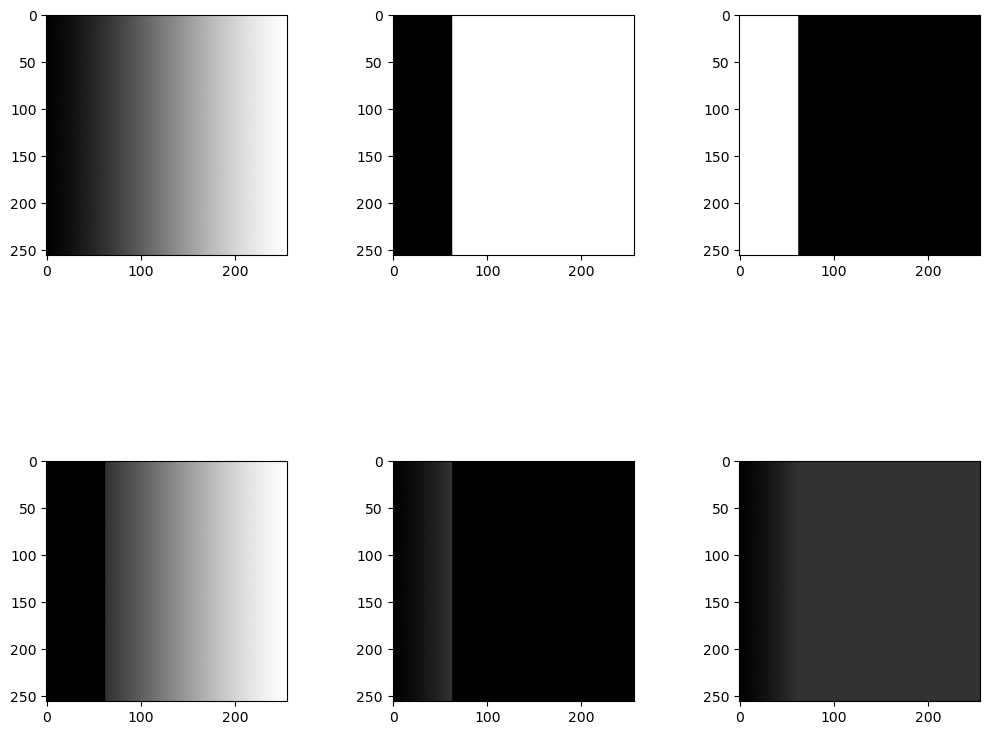

In [10]:
# thresholding variations  -4 change

_, thresh_0 = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
_, thresh_1 = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY_INV)
_, thresh_2 = cv2.threshold(img, 50, 255, cv2.THRESH_TOZERO)
_, thresh_3 = cv2.threshold(img, 50, 255, cv2.THRESH_TOZERO_INV)
_, thresh_4 = cv2.threshold(img, 50, 255, cv2.THRESH_TRUNC)
images = [img, thresh_0,thresh_1, thresh_2, thresh_3,thresh_4]
fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize = (10,10))
for ind, p in enumerate(images):
    ax = axs[ind//3, ind%3]
    ax.imshow(p)
plt.tight_layout(w_pad = 5)
plt.show()

## Adaptive Threshold

In [11]:
img_text = cv2.imread('image/text.jpg')
img = cv2.cvtColor(img_text, cv2.COLOR_BGR2GRAY)

# Adaptive Threshold

_, thresh_binary = cv2.threshold(img, thresh = 127, maxval = 255, type = cv2.THRESH_BINARY)
adap_mean_2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 7, 2)
adap_mean_2_inv = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 7, 2)
adap_mean_8 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 7, 8)
adap_Gauss_8 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 7, 8)

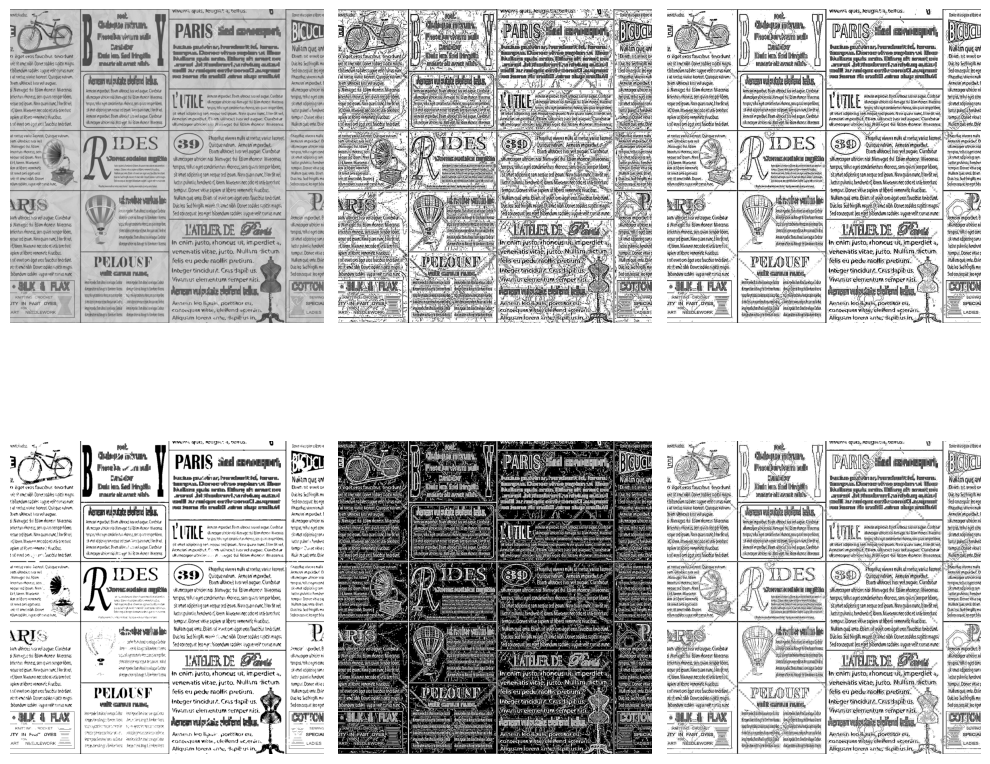

In [12]:
images = [img, thresh_binary,adap_mean_2, adap_mean_2_inv, adap_mean_8,adap_Gauss_8]
fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize = (10,10))
for ind, p in enumerate(images):
    ax = axs[ind%2, ind//2]
    ax.imshow(p, cmap = 'gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Gradient

In [13]:
img_text = cv2.imread('image/text.jpg')
img = cv2.cvtColor(img_text, cv2.COLOR_BGR2GRAY)

In [14]:
# Apply gradient filtering
sobel_x = cv2.Sobel(img, cv2.CV_64F, dx = 1, dy = 0, ksize = 5)
sobel_y = cv2.Sobel(img, cv2.CV_64F, dx = 0, dy = 1, ksize = 5)
blended = cv2.addWeighted(src1=sobel_x, alpha=0.5, src2=sobel_y, beta=0.5, gamma=0)
laplacian = cv2.Laplacian(img, cv2.CV_64F)

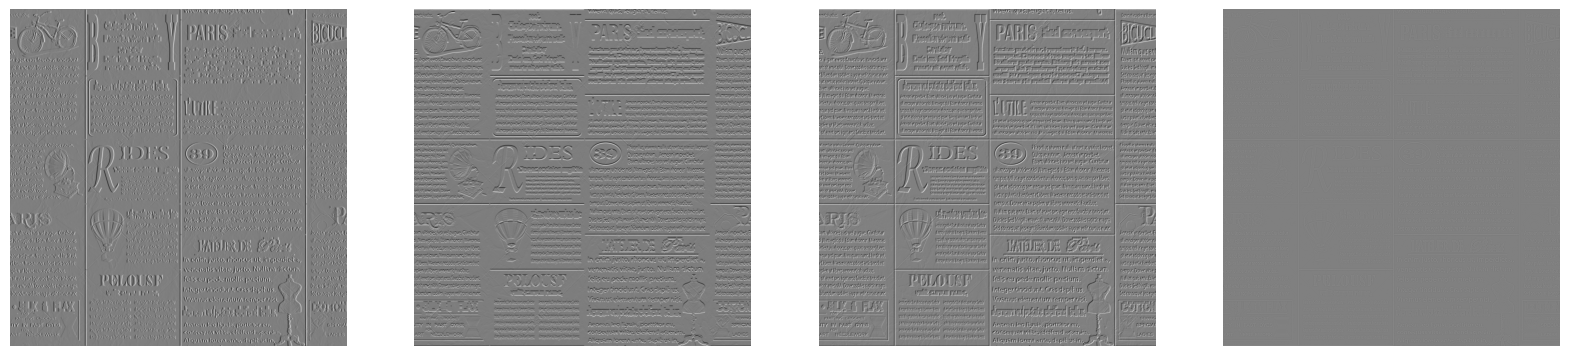

In [15]:
# Plot the images
images = [sobel_x, sobel_y, blended, laplacian]

plt.figure(figsize = (20, 20))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap = 'gray')
    plt.axis('off')
plt.show()

